# Evaluación de modelos de clasificación de reseñas de Yelp

Este notebook constituye la fase de evaluación supervisada del proyecto de análisis de reseñas de Yelp. A partir del texto de cada reseña se intenta predecir su valoración original, expresada en una escala de **1 a 5 estrellas**.

## Objetivo

La pregunta principal es: **¿qué representación del texto permite predecir mejor el rating de una reseña?** Para responderla, se comparan cuatro alternativas con distintos niveles de complejidad:

- **VADER:** referencia basada en un diccionario de sentimiento y reglas léxicas.
- **TF-IDF con unigramas:** representa palabras individuales según su importancia en el corpus.
- **TF-IDF con unigramas y bigramas:** incorpora combinaciones de dos palabras para capturar contexto local y negaciones.
- **Embeddings de oración:** representan el contenido semántico de cada reseña mediante vectores densos preentrenados.

En los tres modelos supervisados, la representación textual se combina con una **regresión logística**. De este modo, la comparación se centra principalmente en la información que aporta cada representación y no en utilizar algoritmos clasificadores completamente distintos.

## Datos y diseño experimental

El corpus contiene reseñas previamente enriquecidas con variables de texto, rating y embeddings. Se separa de forma estratificada en un conjunto de entrenamiento, utilizado para aprender los modelos, y un conjunto de prueba, reservado para medir su generalización sobre datos no vistos.

El target está desbalanceado: las reseñas de 5 estrellas son mucho más frecuentes que las de 1 y 2 estrellas. Por ello, la exactitud global no es suficiente para valorar el sistema. Se utiliza `class_weight="balanced"` en la regresión logística y se toma **Macro-F1** como métrica principal, ya que otorga el mismo peso a cada estrella.

F1 mide qué tan bien un modelo acierta para una sola clase, combinando precisión (de lo que predijo como esa clase, cuánto acertó) y recall (de todo lo que era esa clase, cuánto detectó). Macro-F1 calcula ese F1 para cada una de las 5 clases por separado y luego las promedia dándole el mismo peso a todas, sin importar que 5★ tenga miles de reseñas y 2★ tenga solo unos cientos.

## Cómo se interpretan los resultados

Además de Macro-F1, se analizan:

- **Balanced Accuracy:** promedio del recall de las cinco clases.
- **Recall de 1-2 estrellas:** capacidad para detectar reseñas claramente negativas.
- **Métricas por clase:** permiten localizar clases débiles o difíciles de distinguir.
- **Matriz de confusión normalizada:** muestra si los errores se concentran entre ratings cercanos, como 4 y 5 estrellas.

El notebook está organizado en cinco pasos: preparación del target, división de los datos, definición de la evaluación, entrenamiento de los modelos y comparación final. Las conclusiones se interpretan como resultados predictivos de este corpus concreto, no como relaciones causales entre el lenguaje y la satisfacción del cliente.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix,
)
from sklearn.dummy import DummyClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib


In [3]:
yelp_df = pd.read_parquet("data/yelp_enriquecido.parquet")
X_embeddings = np.load("data/embeddings_oracion.npy")
 
print(f"Reseñas: {len(yelp_df)} | Embeddings: {X_embeddings.shape}")

Reseñas: 19894 | Embeddings: (19894, 384)


### Comprobación de los datos

El corpus contiene **19.894 reseñas** y cada una está representada por un embedding de **384 componentes**. La correspondencia entre el número de reseñas y el número de embeddings confirma que ambas fuentes están alineadas para la evaluación.

## 1. Preparación del target

Se utiliza `Rating` como variable objetivo con cinco clases: de 1 a 5 estrellas. Se conserva la escala original para distinguir entre valoraciones cercanas.

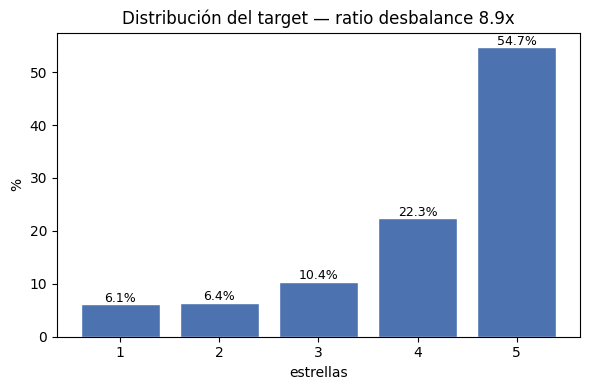

Ratio clase mayoritaria/minoritaria: 8.9x → justifica class_weight='balanced' y Macro-F1 como métrica principal.


In [8]:
yelp_df["target_5c"] = yelp_df["Rating"].astype(int)
 
dist = yelp_df["target_5c"].value_counts(normalize=True).sort_index() * 100
ratio_desbalance = dist.max() / dist.min()
 
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist.index.astype(str), dist.values, edgecolor="white", color="#4c72b0")
ax.set_title(f"Distribución del target — ratio desbalance {ratio_desbalance:.1f}x")
ax.set_xlabel("estrellas"); ax.set_ylabel("%")
for i, v in enumerate(dist.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
 
print(f"Ratio clase mayoritaria/minoritaria: {ratio_desbalance:.1f}x "
      "→ justifica class_weight='balanced' y Macro-F1 como métrica principal.")

El target está claramente desbalanceado: las reseñas de **5 estrellas representan el 54,7 %**, mientras que las de 1 estrella representan el 6,1 %. La razón entre la clase mayoritaria y la minoritaria es **8,9x**.

Por este motivo, la exactitud global podría resultar engañosa. `Macro-F1` y `Balanced Accuracy` son más informativas porque ponderan por igual las cinco clases, y `class_weight="balanced"` reduce la ventaja de las clases frecuentes durante el entrenamiento.

## 2. División estratificada y guardado de datos

Se separan el 80 % de las reseñas para entrenamiento y el 20 % para prueba. `stratify` mantiene aproximadamente la misma proporción de estrellas en ambos conjuntos, y `random_state=42` permite reproducir el experimento.

Los CSV y los embeddings se guardan para reutilizar exactamente la misma partición en futuras comparaciones.

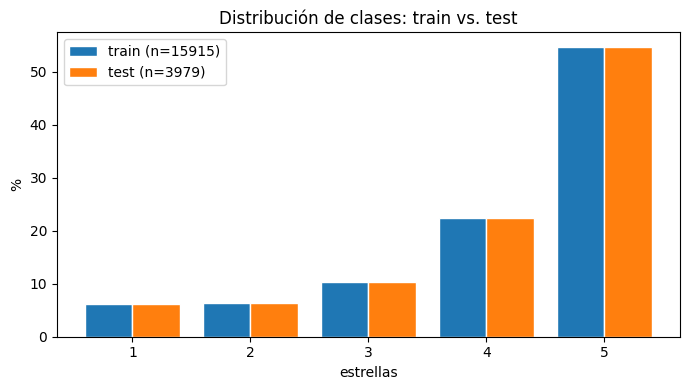

Guardado: train_split.csv (15915), test_split.csv (3979), X_emb_train.npy (15915, 384), X_emb_test.npy (3979, 384)


In [10]:
idx_train, idx_test = train_test_split(
    yelp_df.index, test_size=0.2,
    stratify=yelp_df["target_5c"], random_state=42,
)
 
train_df = yelp_df.loc[idx_train].reset_index(drop=True)
test_df = yelp_df.loc[idx_test].reset_index(drop=True)
 
pos_train = yelp_df.index.get_indexer(idx_train)
pos_test = yelp_df.index.get_indexer(idx_test)
X_emb_train, X_emb_test = X_embeddings[pos_train], X_embeddings[pos_test]
 
# --- Verificación visual de la estratificación: barras agrupadas train vs test ---
dist_train = train_df["target_5c"].value_counts(normalize=True).sort_index() * 100
dist_test = test_df["target_5c"].value_counts(normalize=True).sort_index() * 100
 
x = np.arange(5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, dist_train.values, width=0.4, label=f"train (n={len(train_df)})", edgecolor="white")
ax.bar(x + 0.2, dist_test.values, width=0.4, label=f"test (n={len(test_df)})", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(dist_train.index.astype(str))
ax.set_xlabel("estrellas"); ax.set_ylabel("%")
ax.set_title("Distribución de clases: train vs. test")
ax.legend(); plt.tight_layout(); plt.show()
 
# --- Guardado en CSV ---
train_df.to_csv("data/train_split.csv", index=False)
test_df.to_csv("data/test_split.csv", index=False)
np.save("data/X_emb_train.npy", X_emb_train)
np.save("data/X_emb_test.npy", X_emb_test)
print(f"Guardado: train_split.csv ({len(train_df)}), test_split.csv ({len(test_df)}), "
      f"X_emb_train.npy {X_emb_train.shape}, X_emb_test.npy {X_emb_test.shape}")

La partición contiene **15.915 reseñas de entrenamiento** y **3.979 de prueba**. Las barras de train y test mantienen prácticamente la misma proporción de cada estrella.

## 3. Función de evaluación

Todos los modelos se evalúan con el mismo conjunto de prueba y las mismas métricas:

- **Macro-F1:** métrica principal; da el mismo peso a las cinco estrellas.
- **Balanced Accuracy:** promedio del recall de cada clase.
- **Recall de 1-2 estrellas:** mide cuántas reseñas claramente negativas se recuperan.
- **Métricas por clase y matriz de confusión:** muestran qué ratings se confunden entre sí.

Esta combinación permite valorar tanto el rendimiento global como la capacidad de detectar experiencias negativas.

In [11]:
resultados = []   # una fila por modelo, para la comparación final (sección 5)
 
def evaluar_modelo(nombre, y_true, y_pred, guardar=True):
    """Métrica PRINCIPAL: Macro-F1 (promedia el F1 de las 5 clases con
    igual peso, para que 2★/3★ pesen tanto como 5★ pese a tener menos
    ejemplos). Secundarias: F1 por clase, Balanced Accuracy, Recall de
    1-2★, y matriz de confusión — todo mostrado como gráfico, no tabla."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = [1, 2, 3, 4, 5]
 
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    recall_neg = recall_score(y_true <= 2, y_pred <= 2, zero_division=0)
 
    # Métricas por clase (para el gráfico de barras, no para imprimir tabla)
    f1_clase = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    prec_clase = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    rec_clase = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
 
    print(f"\n{nombre}  →  Macro-F1 = {macro_f1:.3f}  |  "
          f"Balanced Acc = {bal_acc:.3f}  |  Recall 1-2★ = {recall_neg:.3f}")
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
    # --- Gráfico 1: precisión/recall/F1 por clase ---
    x = np.arange(len(labels))
    w = 0.25
    axes[0].bar(x - w, prec_clase, width=w, label="precision")
    axes[0].bar(x, rec_clase, width=w, label="recall")
    axes[0].bar(x + w, f1_clase, width=w, label="F1")
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0, 1.05); axes[0].set_xlabel("estrellas")
    axes[0].set_title("Métricas por clase"); axes[0].legend(fontsize=8)
 
    # --- Gráfico 2: matriz de confusión normalizada ---
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False)
    axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
    axes[1].set_title("Matriz de confusión")
 
    fig.suptitle(nombre, fontsize=11)
    plt.tight_layout(); plt.show()
 
    if guardar:
        resultados.append({"modelo": nombre, "macro_f1": macro_f1,
                            "balanced_acc": bal_acc, "recall_neg": recall_neg})
    return macro_f1

## 4. Modelos comparados

1. VADER convertido a cinco clases.
2. TF-IDF con unigramas y regresión logística.
3. TF-IDF con unigramas y bigramas y regresión logística.
4. Embeddings de oración y regresión logística.

La regresión logística utiliza `class_weight="balanced"` para compensar el desequilibrio del target.

### 4.1. VADER como línea base

VADER es un analizador de sentimiento basado en un diccionario léxico y un conjunto de reglas. Asigna a cada reseña una puntuación `compound` entre -1 y 1 a partir de palabras positivas y negativas, negaciones, mayúsculas, signos de puntuación e intensificadores. No aprende de las reseñas de este proyecto ni utiliza `Rating` durante su cálculo.

En este notebook, la puntuación continua de VADER se transforma en cinco clases mediante los cortes `-0.6`, `-0.05`, `0.4` y `0.8`. Esta transformación permite compararlo con los modelos que predicen de 1 a 5 estrellas, pero debe interpretarse como una **aproximación heurística**, no como una calibración estadística del rating.

#### ¿Por qué se incluye?

VADER ocupa deliberadamente el peldaño más bajo y sencillo de la escalera de modelos. No se espera que sea el mejor clasificador; su función es establecer un punto de referencia:

- Mide qué rendimiento puede obtenerse sin entrenar un modelo con los datos.
- Permite comprobar cuánto valor añade aprender directamente del corpus.
- Ayuda a interpretar si la complejidad adicional de TF-IDF, bigramas o embeddings produce una mejora real.

Si un modelo entrenado no superara claramente a VADER, habría que cuestionar si el entrenamiento aporta suficiente valor frente a una regla de sentimiento genérica. Por tanto, VADER no es la solución final, sino el nivel mínimo que los modelos posteriores deberían superar.


1. VADER bucketizado  →  Macro-F1 = 0.335  |  Balanced Acc = 0.323  |  Recall 1-2★ = 0.431


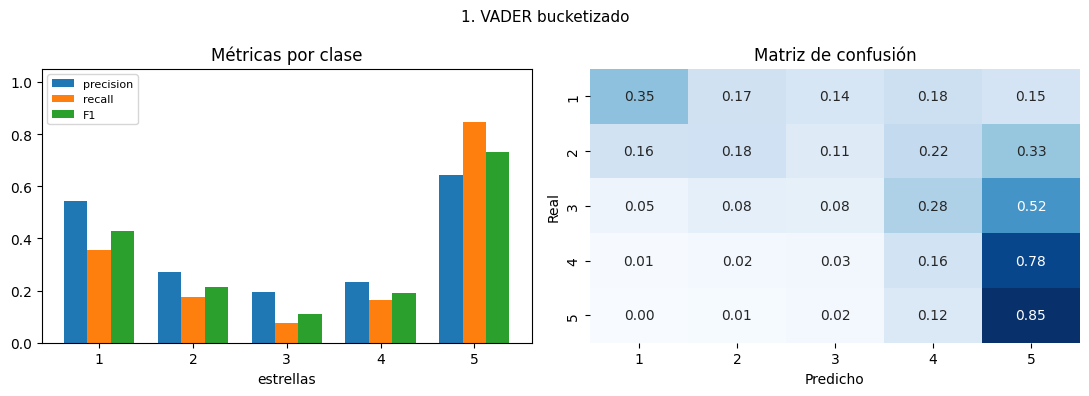

0.33498337379668125

In [14]:
def vader_a_5_clases(v):
    if v <= -0.6: return 1
    if v <= -0.05: return 2
    if v <= 0.4: return 3
    if v <= 0.8: return 4
    return 5
 
pred_vader = test_df["vader"].map(vader_a_5_clases)
evaluar_modelo("1. VADER bucketizado", test_df["target_5c"], pred_vader)

### Resultado de VADER

VADER obtiene un **Macro-F1 de 0,335**, una `Balanced Accuracy` de **0,323** y un recall de **0,431** para las reseñas de 1-2 estrellas. Como referencia no entrenada, detecta parte de la polaridad, pero sus umbrales no distinguen bien las cinco categorías de rating.

### 4.2. TF-IDF con unigramas

TF-IDF representa cada reseña mediante la importancia de sus palabras. La regresión logística aprende qué términos se asocian con cada estrella usando únicamente palabras individuales.

Este modelo permite medir la mejora obtenida al añadir contexto local mediante bigramas.


2. TF-IDF unigramas + LogReg  →  Macro-F1 = 0.519  |  Balanced Acc = 0.546  |  Recall 1-2★ = 0.786


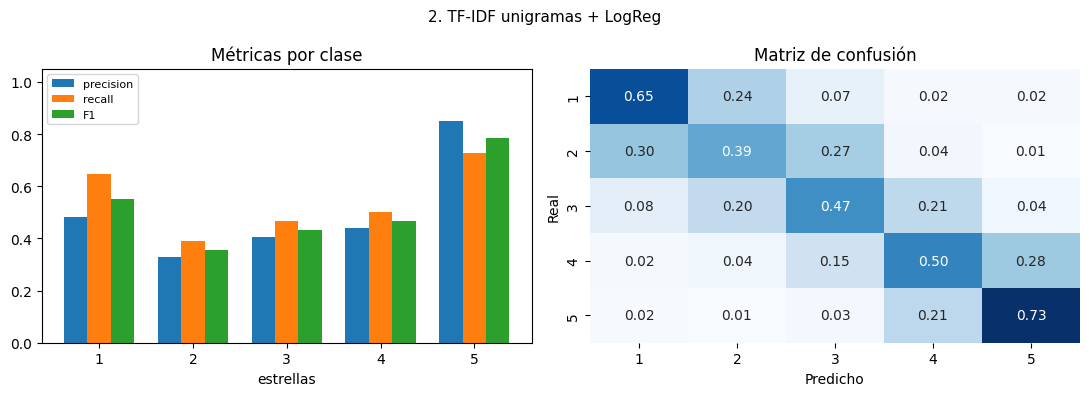

0.5191127834615457

In [16]:
STOPWORDS_BASE = set("""a about after again all am an and any are as at be been being both
by can did do does doing down during each few for from further had has have having he her
here hers herself him himself his how i if in into is it its itself just me more most my
myself of off on once only or other our ours ourselves out own s same she should so some
such t than that the their theirs them themselves then there these they this those through
to too under until up we were what when where which while who whom why will with you your
yours yourself yourselves""".split())
NEGADORES = {"not", "no", "nor", "never", "n't", "very", "too", "but", "however",
             "although", "against", "cannot", "isn", "wasn", "weren", "don", "didn",
             "doesn", "won", "wouldn", "couldn", "shouldn", "hardly", "barely"}
STOPWORDS = STOPWORDS_BASE - NEGADORES
 
pipe_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                               sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
pipe_tfidf.fit(train_df["texto_limpio"], train_df["target_5c"])
pred_tfidf = pipe_tfidf.predict(test_df["texto_limpio"])
evaluar_modelo("2. TF-IDF unigramas + LogReg", test_df["target_5c"], pred_tfidf)

### Resultado de TF-IDF unigramas

El modelo alcanza un **Macro-F1 de 0,519**, una `Balanced Accuracy` de **0,546** y un recall de **0,786** para 1-2 estrellas. La mejora respecto a VADER muestra el valor de aprender directamente del corpus.

La matriz de confusión indica que las clases adyacentes siguen siendo difíciles de separar, especialmente 2 frente a 1 o 3 y 4 frente a 5. Aun así, el modelo recupera correctamente buena parte de las reseñas negativas.

### 4.3. TF-IDF con unigramas y bigramas

Además de palabras individuales, esta versión incorpora pares consecutivos. Los bigramas pueden capturar expresiones cuyo significado depende de la combinación, como negaciones, críticas al servicio o fórmulas de recomendación.


3. TF-IDF bigramas + LogReg  →  Macro-F1 = 0.539  |  Balanced Acc = 0.556  |  Recall 1-2★ = 0.762


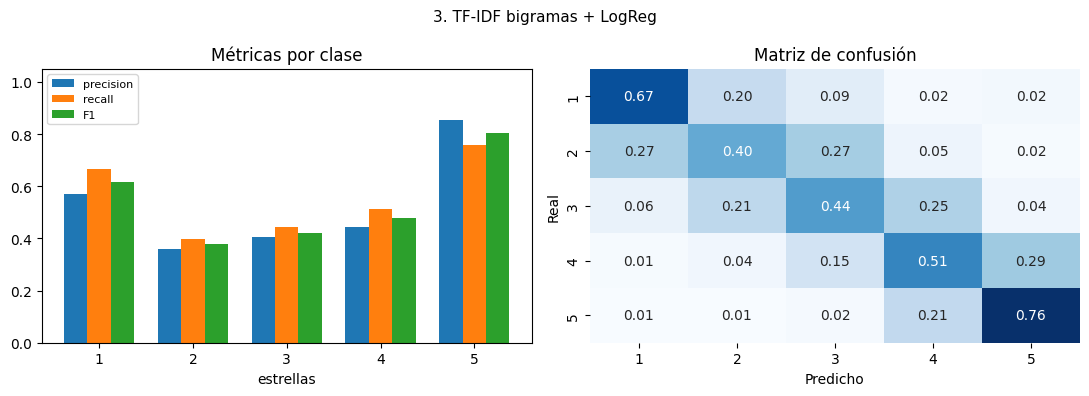

0.5389206368833526

In [17]:
pipe_tfidf_ngram = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                               ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
pipe_tfidf_ngram.fit(train_df["texto_limpio"], train_df["target_5c"])
pred_tfidf_ngram = pipe_tfidf_ngram.predict(test_df["texto_limpio"])
evaluar_modelo("3. TF-IDF bigramas + LogReg", test_df["target_5c"], pred_tfidf_ngram)

### Resultado de TF-IDF con bigramas

Esta versión obtiene el mejor **Macro-F1: 0,539**, junto con una `Balanced Accuracy` de **0,556**. Frente al modelo de unigramas, la mejora es de aproximadamente **0,020 puntos de Macro-F1**, lo que sugiere que el contexto local de dos palabras aporta información útil.

El recall de 1-2 estrellas es **0,762**, ligeramente inferior al de unigramas. Por tanto, los bigramas mejoran el equilibrio global, pero no maximizan la detección de reseñas negativas.

### 4.4. Embeddings de oración

Los embeddings representan el contenido semántico de cada reseña en un vector denso. La regresión logística utiliza esos vectores como entrada, sin aplicar TF-IDF ni volver a entrenar el modelo de lenguaje.


4. Embeddings + LogReg  →  Macro-F1 = 0.473  |  Balanced Acc = 0.507  |  Recall 1-2★ = 0.816


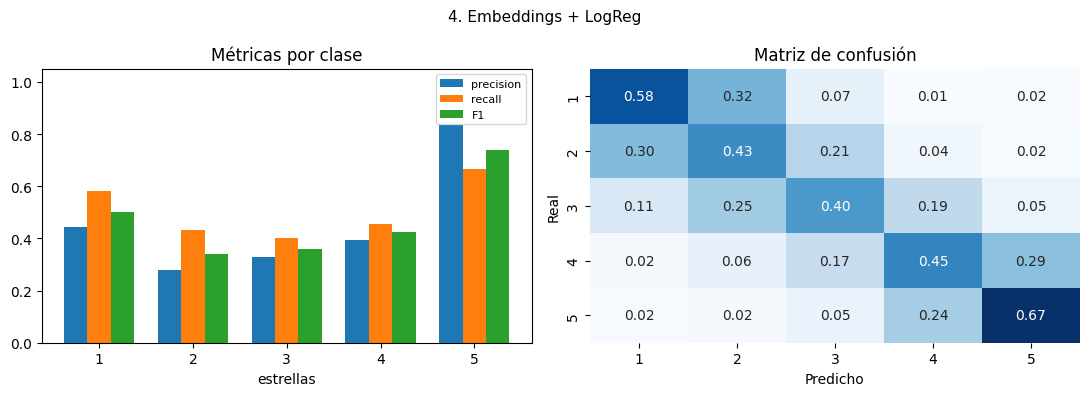

0.47321042286845627

In [18]:
clf_emb = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf_emb.fit(X_emb_train, train_df["target_5c"])
pred_emb = clf_emb.predict(X_emb_test)
evaluar_modelo("4. Embeddings + LogReg", test_df["target_5c"], pred_emb)
 

### Resultado de los embeddings

Los embeddings alcanzan un **Macro-F1 de 0,473** y una `Balanced Accuracy` de **0,507**, por debajo de las dos variantes TF-IDF. Sin embargo, obtienen el mayor recall de 1-2 estrellas (**0,816**), por lo que son la alternativa más sensible para detectar valoraciones negativas.

Este resultado indica que una representación semántica general no siempre supera a una representación léxica adaptada a un corpus pequeño y específico. El rendimiento podría cambiar con ajuste de hiperparámetros, otro modelo de embeddings o más datos de entrenamiento.

## 5. Comparación final

Se reúnen las métricas de todos los modelos en un único gráfico. El orden se establece por Macro-F1, la métrica principal, mientras que Balanced Accuracy y Recall de 1-2 estrellas ayudan a interpretar los objetivos secundarios.

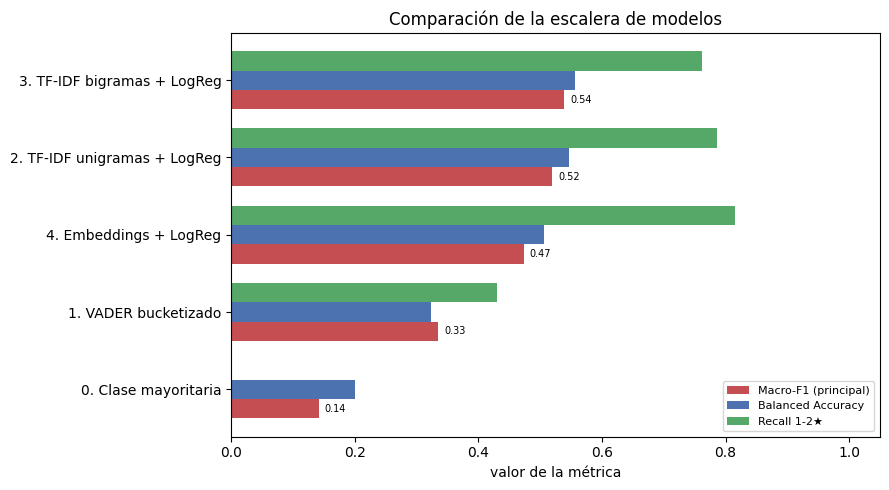

Mejor modelo: 3. TF-IDF bigramas + LogReg  →  Macro-F1 = 0.539
Compara este número contra el desacuerdo fuerte de VADER (~8.6% en el
corpus real) para decidir si vale la pena un transformer (BERT) después.


In [19]:
tabla = pd.DataFrame(resultados).sort_values("macro_f1", ascending=True)
 
x = np.arange(len(tabla))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(x - w, tabla["macro_f1"], height=w, label="Macro-F1 (principal)", color="#c44e52")
ax.barh(x, tabla["balanced_acc"], height=w, label="Balanced Accuracy", color="#4c72b0")
ax.barh(x + w, tabla["recall_neg"], height=w, label="Recall 1-2★", color="#55a868")
ax.set_yticks(x); ax.set_yticklabels(tabla["modelo"])
ax.set_xlabel("valor de la métrica"); ax.set_xlim(0, 1.05)
ax.set_title("Comparación de la escalera de modelos")
ax.legend(loc="lower right", fontsize=8)
for i, (mf1, ba, rn) in enumerate(zip(tabla["macro_f1"], tabla["balanced_acc"], tabla["recall_neg"])):
    ax.text(mf1 + 0.01, i - w, f"{mf1:.2f}", va="center", fontsize=7)
plt.tight_layout(); plt.show()
 
mejor = tabla.iloc[-1]
print(f"Mejor modelo: {mejor['modelo']}  →  Macro-F1 = {mejor['macro_f1']:.3f}")
print("Compara este número contra el desacuerdo fuerte de VADER (~8.6% en el\n"
      "corpus real) para decidir si vale la pena un transformer (BERT) después.")

### Guardar el mejor modelo entrenado

In [25]:
# Diccionario que traduce el nombre legible al pipeline real en memoria.
nombre_mejor = mejor["modelo"]
modelos_entrenados = {
    "2. TF-IDF unigramas + LogReg": pipe_tfidf,
    "3. TF-IDF bigramas + LogReg": pipe_tfidf_ngram,
    "4. Embeddings + LogReg": clf_emb,
}

joblib.dump(modelos_entrenados[nombre_mejor], "data/mejor_modelo.joblib")
print(f"Modelo guardado en data/mejor_modelo.joblib: {nombre_mejor}")

Modelo guardado en data/mejor_modelo.joblib: 3. TF-IDF bigramas + LogReg


### Conclusiones

El mejor modelo según la métrica principal es **TF-IDF con unigramas y bigramas + Regresión Logística**, con Macro-F1 = **0,539** y Balanced Accuracy = **0,556**. Es la opción más equilibrada para predecir las cinco estrellas y supera tanto a VADER como a TF-IDF con unigramas.

Los resultados también dependen del objetivo:

- Para maximizar el equilibrio entre las cinco clases, conviene elegir el modelo con bigramas.
- Para recuperar el mayor número posible de reseñas de 1-2 estrellas, los embeddings ofrecen el recall más alto (**0,816**).
- VADER funciona como línea base interpretable, pero no como solución final para una clasificación detallada.

Las matrices de confusión muestran que los errores se concentran en ratings vecinos, especialmente entre 1-2, 2-3 y 4-5 estrellas. Esto es esperable: una reseña de 3 y otra de 4 pueden compartir vocabulario positivo, aunque expresen distinta intensidad.

### Limitaciones y próximos pasos

El desbalance del target y la cercanía semántica entre clases aconsejan complementar estas métricas con validación cruzada estratificada, intervalos de variación y revisión de errores. También sería útil comprobar la generalización por fecha o por restaurante para evitar resultados optimistas causados por reseñas muy parecidas.

El salto a BERT o a otro transformer solo estaría justificado después de optimizar los modelos TF-IDF, revisar ejemplos mal clasificados y comparar el coste computacional con una mejora medible sobre Macro-F1.